## Second Homework: Network Optimization and Non-linear Models (Topics 2, 3)

By Álvaro Martín Ruiz and Jaime Salafranca Pardo

Network optimization: one optimization model with discrete variables and a network structure
You can get inspiration from the models in this book:
Network Optimization: Continuous and Discrete Models
where you can re-adapt a model using your own data to add originality


(5 points) Formulate the network optimization problem as a discrete model (Topic 2), identifying
mathematically the variables and constraints associated with the network. Solve and interpret the
solution.

### Introduction to the problem:

This project focuses on optimizing the Formula 1 (F1) race calendar for 2024 by leveraging mathematical programming techniques. The goal is to minimize the total travel distance between circuits while adhering to strict scheduling constraints, including specific dates allocated to particular circuits. The optimization incorporates a predefined list of Sundays from the 2024 calendar, aligning with real-world event planning requirements.

The model uses a distance matrix to represent the travel distances between circuits. It ensures logical scheduling by enforcing constraints such as:

Start and End Points: Ensuring the sequence begins at a specified circuit and concludes at another.
Flow Balance: Maintaining inflow and outflow constraints to ensure a complete circuit path.
Subtour Elimination: Preventing the formation of isolated loops that do not cover all circuits.
Date Assignments: Assigning specific dates to circuits in accordance with predefined constraints, reflecting the F1 2024 scheduling.
Using Gurobi as the solver, the model seeks an optimized schedule that reduces logistical costs while satisfying all constraints. This project compares the resulting optimized calendar against the official 2024 F1 calendar to identify potential improvements in travel efficiency and scheduling feasibility.

1. First the data will be loaded and explained
2. The mathematical Formulas will be explained
3. The pyomo model will be created

In [1]:
import pandas as pd
import random
from pyomo.environ import *
from pyomo.opt import SolverFactory
from geopy.distance import geodesic

# Set random seed for reproducibility
seed = 10
random.seed(seed)

## Data Loading and Preprocessing

The project uses two datasets: circuits and races. The circuits dataset contains information about various F1 circuits worldwide, including their names, locations, and geographical coordinates. We select the indices of specific circuits in 2024 and add three new circuits to the dataset as it is very recent circuit that doen't appear in teh dataset but where raced in 2024.

In [2]:

# Load datasets
dataset = pd.read_csv("circuits.csv", encoding='latin-1')
dataset_races = pd.read_csv("races.csv", encoding='latin-1')

# Calculate popularity (number of races per circuit)
popularity = dataset_races.groupby("circuitId").size().reset_index(name='count')
popularity.columns = ['circuitId', 'count']

# Merge popularity into dataset
dataset = dataset.merge(popularity, on="circuitId", how="left")
dataset['count'] = dataset['count'].fillna(0)  # Replace NaN with 0 for circuits with no races

# Filter selected circuits
indices = [0, 2, 3, 5, 6, 8, 10, 12, 13, 14, 16, 17, 20, 21, 23, 31, 38, 43, 68, 69, 72]
selected_names = dataset.loc[indices]

# Define new circuits
new_circuits = pd.DataFrame({
    'circuitId': [81, 82, 83],
    'circuitRef': ['losail', 'jeddah', 'miami'],
    'name': ['Losail International Circuit', "Jeddah's Street Circuit", 'Miami Circuit'],
    'location': ['Al Daayen', 'Jeddah', 'Miami'],
    'country': ['Qatar', 'Saudi Arabia', 'USA'],
    'lat': [25.49, 21.543333, 25.958056],
    'lng': [51.454167, 39.172778, -80.238889]
})

# Append new circuits to the selected dataset
data = pd.concat([selected_names, new_circuits], ignore_index=True)
data['name']

0     Albert Park Grand Prix Circuit
1      Bahrain International Circuit
2     Circuit de Barcelona-Catalunya
3                  Circuit de Monaco
4          Circuit Gilles Villeneuve
5                Silverstone Circuit
6                        Hungaroring
7       Circuit de Spa-Francorchamps
8       Autodromo Nazionale di Monza
9          Marina Bay Street Circuit
10    Shanghai International Circuit
11      AutÌ_dromo JosÌ© Carlos Pace
12     Autodromo Enzo e Dino Ferrari
13                    Suzuka Circuit
14                Yas Marina Circuit
15    AutÌ_dromo Hermanos RodrÌ_guez
16            Circuit Park Zandvoort
17          Las Vegas Street Circuit
18           Circuit of the Americas
19                     Red Bull Ring
20                 Baku City Circuit
21      Losail International Circuit
22           Jeddah's Street Circuit
23                     Miami Circuit
Name: name, dtype: object

We can the index and name of teh 24 circuits of teh 2024 calendar.

# Calculating the Distance Matrix

In this section, we calculate a distance matrix to find the pairwise distances between coordinates in our dataset. The **Haversine formula** or a similar geodesic distance computation is used to calculate the shortest path on the Earth's surface between two points defined by their latitude and longitude.

---

## Mathematical Explanation

### Geodesic Distance Formula

The geodesic distance between two points $$(\text{lat}_1, \text{lon}_1) and (\text{lat}_2, \text{lon}_2)$$ on the Earth's surface is computed using the following formula:

$$
d = R \cdot \Delta\sigma
$$

Where:

- \(d\): Geodesic distance
- \(R\): Earth's radius (mean radius = 6371 km)
- \(\Delta\sigma\): Central angle between the two points (in radians)

The central angle \(\Delta\sigma\) is given by:

$$
\Delta\sigma = \arccos\left(\sin(\text{lat}_1) \cdot \sin(\text{lat}_2) + \cos(\text{lat}_1) \cdot \cos(\text{lat}_2) \cdot \cos(\Delta\lambda)\right)
$$

Where:

$$\Delta\lambda = \text{lon}_2 - \text{lon}_1$$ is the difference in longitude.

Alternatively, libraries like `geopy` compute this distance using high-precision geodesic models such as WGS-84.

---

### Distance Matrix

The **distance matrix** is represented as a dictionary where each key corresponds to a pair of indices \((i, j)\), and the value is the computed distance between the two points. It is formally defined as:

$$
\text{DistanceMatrix}[i, j] =
\begin{cases}
\text{calculate\_distance}(\text{lat}_i, \text{lon}_i, \text{lat}_j, \text{lon}_j), & i \neq j \\
\text{undefined}, & i = j
\end{cases}
$$

Where:

- \(i, j\) are indices of the points in the dataset.
- $\text{calculate\_distance}$ is the function implementing the geodesic distance formula.

---



In [3]:
# Calculate distance matrix
def calculate_distance(lat1, lon1, lat2, lon2):
    return geodesic((lat1, lon1), (lat2, lon2)).kilometers

num_circuits = len(data)
distance_matrix = {
    (i, j): calculate_distance(data.iloc[i]['lat'], data.iloc[i]['lng'], data.iloc[j]['lat'], data.iloc[j]['lng'])
    for i in range(num_circuits) for j in range(num_circuits) if i != j
}

We now select the number of Weekends that will have a race. We select the number of weekends that are raced in 2024 the season starts early March and ends early December. The month of August will be race free as all teh years. The index of each date will be relevant as it will be necesary to select the date when the date of a circuit is a conbstraint.

In [4]:
from datetime import timedelta, date
def generate_sundays(year):
    sundays = []
    d = date(year, 1, 1)
    d += timedelta(days=(6 - d.weekday()))  # Move to first Sunday
    while d.year == year:
        sundays.append(d)
        d += timedelta(weeks=1)  # Move to the next Sunday
    return sundays

sundays_2024 = generate_sundays(2024)[8:29] + generate_sundays(2024)[35:49]
sundays_df = pd.DataFrame({
    'Index': range(1, len(sundays_2024) + 1),
    'Sunday Date': [sunday.strftime("%d %B %Y") for sunday in sundays_2024]
})
sundays_df

,Index,Sunday Date
0,1,03 March 2024
1,2,10 March 2024
2,3,17 March 2024
3,4,24 March 2024
4,5,31 March 2024
5,6,07 April 2024
6,7,14 April 2024
7,8,21 April 2024
8,9,28 April 2024
9,10,05 May 2024


### B) MATHEMATICAL MODELS AND FORMULAS.

## Components of the Model

### 1. **Model Declaration**

We declare the model as a `ConcreteModel`, which is used for optimization problems with defined variables, sets, and constraints.

2. Sets
 * `model.Circuits` : A set representing the circuits or nodes in the optimization problem. The set includes all circuit indices from 0 to num_circuits - 1, where num_circuits is the total number of circuits.

* `model.Arcs` : A set representing the arcs or edges between circuits. The set is initialized with the keys of the distance matrix, which are pairs of circuit indices (i, j).

* `model.I`, `model.J` : Sets used for indexing in constraints.

3. Decision Variables

* `model.x` : Binary decision variables representing the presence of an arc between two circuits. If x[i, j] = 1, there is a connection between circuits i and j; otherwise, x[i, j] = 0.

* `model.u` : Subtour elimination variables used to prevent the formation of isolated loops in the circuit path. The variables are bounded between 1 and num_circuits - 1.

* `model.date_order` : Non-negative integer variables representing the order of circuits based on the assigned dates. The variables are bounded between 0 and the total number of Sundays in 2024.


### 2. Objective Function Declaration


The objective function is defined to minimize the total distance traveled across all arcs. It is formulated as follows:

$$
\text{Minimize} \quad \sum_{(i, j) \in \text{Arcs}} x_{ij} \cdot d_{ij}
$$

Where:

- $ x_{ij} $ is a binary decision variable that equals 1 if the arc between circuit \( i \) and circuit $ j $ is selected, and 0 otherwise.
- $ d_{ij} $ is the distance between circuit $ i $ and circuit \( j \) from the `distance_matrix`.
- The summation runs over all pairs of circuits $ (i, j) $ in the set of arcs.

This objective function minimizes the total distance traveled across the selected arcs, ensuring the optimal routing of circuits.


### 3. TSM Problem CONSTRAINTS FORMULATION

### Explanation of the Mathematics Behind the Constraints

#### 1. **Inflow Rule**
The `inflow_rule` ensures that each circuit node (except the starting and ending circuits) has exactly **one inflow**. This means one incoming connection to the node:

- **Mathematical Representation**:
  $$
  \sum_{j \in \text{Circuits}, j \neq i} x_{j,i} = 1, \quad \forall i \neq \text{start\_circuit}, \, i \neq \text{end\_circuit}
  $$
  Where:
  - $ x_{j,i} $ is a binary decision variable (1 if there is a flow from circuit $ j $ to circuit $ i $, 0 otherwise).
  - The summation considers all incoming flows into $ i $ from $ j $, excluding $ i $ itself.

- **Behavior**:
  - If $ i $ is the `start_circuit` or `end_circuit`, this constraint is skipped.

---

#### 2. **Outflow Rule**
The `outflow_rule` ensures that each circuit node (except the starting and ending circuits) has exactly **one outflow**. This means one outgoing connection from the node:

- **Mathematical Representation**:
  $$
  \sum_{j \in \text{Circuits}, j \neq i} x_{i,j} = 1, \quad \forall i \neq \text{start\_circuit}, \, i \neq \text{end\_circuit}
  $$
  Where:
  - $ x_{i,j} $ is a binary decision variable (1 if there is a flow from circuit $ i $ to circuit $ j $, 0 otherwise).
  - The summation considers all outgoing flows from $ i $ to $ j $, excluding $ i $ itself.

- **Behavior**:
  - If $ i $ is the `start_circuit` or `end_circuit`, this constraint is skipped.

---

#### 3. **Cycle Constraint Rule**
The `cycle_constraint_rule` enforces the elimination of subtours (cycles) within the solution to the routing problem. This ensures that the flow adheres to a single path visiting all nodes exactly once:

- **Mathematical Representation**:
  $$
  u_i - u_j + 1 \leq (n-1) \cdot (1 - x_{i,j}), \quad \forall i \neq j, \, i \neq \text{start\_circuit}, \, j \neq \text{start\_circuit}
  $$
  Where:
  - $u_i $ and $ u_j $ are auxiliary variables representing the order of visiting nodes $ i $ and $ j $.
  - $ n $ is the total number of circuits (nodes).
  - If $ x_{i,j} = 1 $, the order difference between $ i $ and $ j $ must satisfy $ u_i - u_j + 1 \leq 0 $, thus enforcing proper sequencing.

- **Behavior**:
  - If $ i = \text{start\_circuit} $ or $ j = \text{start\_circuit} $, the constraint is skipped.

---

### Summary
These constraints collectively model a **traveling salesman problem (TSP)** or a **routing problem**:
- The `inflow_rule` and `outflow_rule` ensure a single flow into and out of each node, maintaining connectivity.
- The `cycle_constraint_rule` prevents the formation of disjoint cycles, enforcing a single, connected tour that visits all nodes once.


### 4. DATE CONSTRAINTS

### Explanation of the `date_order_constraint`

This constraint enforces an order on the "dates" associated with the arcs in a model, ensuring logical sequencing of visits based on the flow between nodes. It prevents illogical orderings in a routing or scheduling problem.

---

#### **Mathematical Representation**
$$
\text{date\_order}[i] + 1 \leq \text{date\_order}[j] + (1 - x[i,j]) \cdot |S|,
$$
where:
- $ \text{date\_order}[i] $: Represents the date order for node $ i $.
- $ x[i, j] $: A binary variable indicating whether there is a flow from $ i $ to $ j $ ($1$ if there is a flow, $0$ otherwise).
- $ |S| $: The total number of Sundays in 2024, used as a large constant to relax the constraint when $ x[i, j] = 0 $.

---

#### **Behavior**
1. **When $ x[i,j] = 1 $:**
   - The flow exists from node $ i $ to node $ j $.
   - The constraint simplifies to:
     $
     \text{date\_order}[i] + 1 \leq \text{date\_order}[j],
     $
     enforcing that the date at node $ j $ must be strictly greater than the date at node $ i $.

2. **When $ x[i,j] = 0 $:**
   - There is no flow from node $ i $ to node $ j $.
   - The term $ (1 - x[i, j]) \cdot |S| $ becomes large (since $ |S| $ is a large constant), effectively relaxing the constraint:
     $
     \text{date\_order}[i] + 1 \leq \text{date\_order}[j] + |S|,
     $
     which always holds because the large constant $ |S| $ dominates.

---

#### **Purpose**
This constraint ensures that:
- If there is a flow from $ i $ to $ j $, the order of $ j $ in the date sequence must follow $ i $ (i.e., $ i $ is visited before $ j $).
- Prevents cycles or invalid orders in scheduling, aligning the solution with a valid temporal sequence.

---

#### **Constraint Skipping**
The constraint is skipped for arcs where $ i = j $, as a node cannot point to itself.

---

#### **Context: Sundays in 2024**
The term $ |S| $, representing the number of Sundays in 2024, acts as a large constant to relax the constraint when needed. Its role is purely technical, ensuring the constraint does not interfere with infeasible arcs ($ x[i, j] = 0 $).


### 5. YEAR SPECIFIC CONSTRAINTS

### Explanation of 2024 Calendar-Specific Constraints for Formula 1

The constraints mentioned are specific to the scheduling of the Formula 1 season in 2024. They ensure that certain races occur on specific dates or within specific timeframes based on historical patterns, traditions, or logistical considerations. Below is a detailed breakdown of each constraint:

---

#### **1. Formula 1 Always Starts in Bahrain and Ends in Abu Dhabi**
- **Constraint**:
  The Bahrain Grand Prix must be the first race of the season, and the Abu Dhabi Grand Prix must be the last.

- **Mathematical Representation**:
  - For Bahrain (let its index be $B$):
    $ \text{date\_order}[B] = 1 $
  - For Abu Dhabi (let its index be $A$):
    $ \text{date\_order}[A] = n $
    Where $n$ is the a grand prix date among the 32 it can only be on the 24th or later as there are 24 races..

- **Purpose**:
  - Bahrain traditionally opens the season due to favorable weather, logistics, and the circuit's preparation.
  - Abu Dhabi traditionally closes the season with its twilight-to-night race format, which is ideal for a grand finale.

---

#### **2. Mexican Grand Prix on Día de los Muertos**
- **Constraint**:
  The Mexican Grand Prix must occur during **Día de los Muertos**, which is celebrated annually on **November 1st and 2nd**.

- **Mathematical Representation**:
  - Let $M$ be the index of the Mexican Grand Prix:
    $ \text{race\_date}[M] = \text{November 1 or 2, 2024} $
  - Alternatively, you could enforce:
    $ \text{date\_order}[M] \in \text{dates surrounding Día de los Muertos in the calendar.} $

- **Purpose**:
  - The Mexican Grand Prix has strong cultural ties to this festival, enhancing the event's atmosphere and making it a spectacle for fans.

---

#### **3. Singapore Grand Prix Always in September**
- **Constraint**:
  The Singapore Grand Prix must occur during the month of **September**.

- **Mathematical Representation**:
  - Let $S$ be the index of the Singapore Grand Prix:
    $$ \text{race\_date}[S] \in \text{September 2024 dates} $$
  - Alternatively, if modeling with an ordinal date:
    $$ \text{date\_order}[S] \in \text{ordinal dates corresponding to September.} $$

- **Purpose**:
  - The Singapore Grand Prix is held as a night race, and September offers optimal weather conditions to avoid the monsoon season. Additionally, it fits well into the global logistics and travel schedule.

---

#### **4. Monaco Grand Prix on a Specific Date**
- **Constraint**:
  The Monaco Grand Prix is traditionally held on the **last Sunday of May**. For 2024, this falls on **May 26th**.

- **Mathematical Representation**:
  - Let $C$ be the index of the Monaco Grand Prix:
    $$ \text{race\_date}[C] = \text{May 26, 2024} $$

- **Purpose**:
  - Monaco is one of the most iconic races in the Formula 1 calendar, and its scheduling is deeply rooted in tradition and logistical arrangements specific to the principality.

---



## C) PYOMO MODEL CREATION

### 1. MODEL DECLARATION

In [6]:
model = ConcreteModel()

# Define sets and variables
model.Circuits = RangeSet(0, num_circuits - 1)  # Circuits set
model.Arcs = Set(initialize=distance_matrix.keys(), dimen=2)  # Arcs set
model.x = Var(model.Arcs, domain=Binary)  # Binary decision variables
model.u = Var(model.Circuits, bounds=(1, num_circuits - 1))  # Subtour elimination variables
model.n = Param(initialize=num_circuits)
model.I = RangeSet(0, model.n - 1)
model.J = RangeSet(0, model.n - 1)

# Define new variable for the order of Sundays assigned to each circuit
model.Sundays = Set(initialize=sundays_2024)

# Modify the date_order variable to represent actual Sundays (dates)
model.date_order = Var(model.Circuits, domain=NonNegativeIntegers, bounds=(0, len(sundays_2024) - 1))


### 2. OBJECTIVE FUNCTION

In [7]:
model.obj = Objective(
    expr=sum(model.x[i, j] * distance_matrix[i, j] for i, j in model.Arcs),
    sense=minimize
)

## 3. TSP CONSTRAINTS FORMULATION

In [8]:
start_circuit = 1
end_circuit = 14

def inflow_rule(model, i):
    if i != start_circuit and i != end_circuit:
        return sum(model.x[j, i] for j in model.Circuits if i != j) == 1
    return Constraint.Skip
model.inflow = Constraint(model.Circuits, rule=inflow_rule)


def outflow_rule(model, i):
    if i != start_circuit and i != end_circuit:
        return sum(model.x[i, j] for j in model.Circuits if i != j) == 1
    return Constraint.Skip
model.outflow = Constraint(model.Circuits, rule=outflow_rule)


def cycle_constraint_rule(model, i, j):
    if (i != 1 and j != 1 and i != j):
        return model.u[i] - model.u[j] + 1 <= (model.n - 1) * (1 - model.x[i, j])
    else:
        return Constraint.Skip
model.cycle_Constraint = Constraint(model.I, model.J, rule=cycle_constraint_rule)


### 4. DATE CONSTRAINTS

In [9]:
def date_order_constraint(model, i, j):
    if i != j:
        return model.date_order[i] + 1 <= model.date_order[j] + (1 - model.x[i, j]) * len(sundays_2024)
    return Constraint.Skip
model.date_order_constraint = Constraint(model.Arcs, rule=date_order_constraint)

### 5. YEAR SPECIFIC CONSTRAINTS

In [10]:
def start_constraint(model):
    return sum(model.x[start_circuit, j] for j in model.Circuits if j != start_circuit) == 1
model.start = Constraint(rule=start_constraint)


def end_constraint(model):
    return sum(model.x[i, end_circuit] for i in model.Circuits if i != end_circuit) == 1
model.end = Constraint(rule=end_constraint)

# MONACO CONSTRAINT
def fixed_date_circuit_1(model):
    return model.date_order[3] == 9  # Circuit 3 must be assigned to date 6
model.fixed_date_circuit_1 = Constraint(rule=fixed_date_circuit_1)

# MEXICO CONSTRAINT
def fixed_date_circuit_2(model):
    return model.date_order[15] == 29  # Circuit 6 must be assigned to date 7
model.fixed_date_circuit_2 = Constraint(rule=fixed_date_circuit_6)


def fixed_date_circuit_3(model):
    return model.date_order[9] == 21  # Circuit 6 must be assigned to date 7
model.fixed_date_circuit_3 = Constraint(rule=fixed_date_circuit_3)

print("Constraints added successfully.")


Constraints added successfully.


In [11]:
# Solve the problem
solver = SolverFactory('gurobi')  # Replace with 'cbc' or 'glpk' if needed
result = solver.solve(model, tee=True)

# Analyze the result
if (result.solver.status == SolverStatus.ok) and (result.solver.termination_condition == TerminationCondition.optimal):
    # Extract the solution
    solution = [(i, j) for i, j in model.Arcs if model.x[i, j]() > 0.5]
    total_distance = model.obj()
    print("Optimal Route:", solution)
    print(f"Total Distance: {total_distance:.2f} km")

else:
    print("Model is infeasible. Check data and constraints.")

# Debugging Outputs
print("Model Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-06
Read LP format model from file C:\Users\jaime\AppData\Local\Temp\tmpmcffu_yv.pyomo.lp
Reading time = 0.02 seconds
x1: 1107 rows, 599 columns, 4235 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22621.2))

CPU model: AMD Ryzen 5 4500U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 6 logical processors, using up to 6 threads

Optimize a model with 1107 rows, 599 columns and 4235 nonzeros
Model fingerprint: 0x20321d60
Variable types: 23 continuous, 576 integer (552 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [1e+02, 2e+04]
  Bounds range     [1e+00, 3e+01]
  RHS range        [1e+00, 3e+01]
Presolve removed 93 rows and 7 columns
Presolve time: 0.01s
Presolved: 1014 rows, 592 columns, 3990 nonzeros
Variable types: 23 continuous, 569 integer (548 binary)

Root relaxation: objective 4.626966

# D. PLOTTING THE RESULTS

### Explanation of the Map Visualization for the Ideal Route

The provided code generates an interactive map using the `folium` library to visualize the ideal route for visiting the Formula 1 circuits based on the Traveling Salesperson Problem (TSP) solution. Here's how it works, along with the conclusion about the comparison with the actual F1 calendar:

* check the date of a circuit by clicking on it.
* check that the connection between bahrain and abu dhabi is not done.

---
### Conclusion: Comparing the Ideal Route to the F1 Calendar

- **Similarity to F1 Calendar**:
  - The generated map visually represents an optimized route for visiting all circuits, potentially resembling the Formula 1 calendar since both aim to minimize travel distance and logistical costs.

- **F1 Constraints**:
  - Despite similarities, the Formula 1 calendar has **additional constraints** that make its actual route less efficient:
    - **Specific Date Assignments**: Races like the Monaco Grand Prix and Mexican Grand Prix must occur on fixed dates, reducing flexibility.
    - **Seasonal Adjustments**: Circuits in certain regions are scheduled to align with favorable weather conditions.
    - **Travel Logistics**: Teams need time to transport equipment, leading to some non-optimal connections between races.
    - **Event Prioritization**: High-profile races like Monaco may take precedence over logistical efficiency.

- **Conclusion on Route Length**:
  - The TSP solution likely produces a **shorter overall route** compared to the actual F1 calendar.
  - The **actual F1 calendar** is longer and less direct due to the interplay of these external constraints, emphasizing the complex trade-offs involved in creating a global sports schedule.


In [12]:
import folium

# Assuming 'data' contains columns 'lat', 'lng', and 'date' for each circuit
circuit_coordinates = {
    circuit: (row['lat'], row['lng']) for circuit, row in data.iterrows()
}

# Step 1: Create a base map centered around the average coordinates
center_lat = sum(coord[0] for coord in circuit_coordinates.values()) / len(circuit_coordinates)
center_lng = sum(coord[1] for coord in circuit_coordinates.values()) / len(circuit_coordinates)
map_tsp = folium.Map(location=[center_lat, center_lng], zoom_start=2)  # Set initial zoom level to 5

# Step 2: Add markers for circuits
for circuit, (lat, lng) in circuit_coordinates.items():
    popup_content = f"<b>Circuit {data['name'][circuit]}</b><br>Date: {sundays_2024[int(model.date_order[circuit]())]}"

    # Create a custom popup with a larger size
    popup = folium.Popup(popup_content, max_width=300)  # Set a larger max_width for the popup

    folium.Marker(
        location=[lat, lng],
        popup=popup,
        tooltip=f"Circuit {circuit}",
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(map_tsp)

# Step 3: Plot the solution route, excluding the last segment
for i, j in solution:  # Exclude the last segment by slicing the solution list
    start_coord = circuit_coordinates[i][:2]  # Getting the latitude and longitude
    end_coord = circuit_coordinates[j][:2]
    folium.PolyLine(
        locations=[start_coord, end_coord],
        color="blue",
        weight=5,
        opacity=0.8,
    ).add_to(map_tsp)

# Step 4: Display the map
map_tsp.save("tsp_solution_map_with_dates.html")
map_tsp



![Calendar](calendar.jpg)


# SECOND PART
b) (5 points) Formulate (mathematically) and solve a non-linear optimization problem based on real
(or realistic) world data. Interpret the solution.


# Textual description of the problem

For this problem, we will play the role of a boutique investment firm, **UC3M Hedge Fund**, known for its innovative strategies and the use of cuttind-edge tecgnology to decide in what to invest. Our clients want exposure to the **American market**, particularly the **S&P 500 Index**, which represents the performance of 500 of the largest publicly traded companies in the United States.

However, we face a challenge. Buying all 500 stocks in the index is not practical for a firm like ours due to:
1. **High Transaction Costs**: Purchasing and maintaining such a large number of positions incurs significant trading fees.
2. **Complexity**: Managing such a broad portfolio requires substantial resources and infrastructure.

Another option would be to invest in an **indexed mutual fund or ETF**. However:
- Many of these funds charge **management fees**, which, while small, can significantly impact long-term returns.

---

### Our Innovative Solution

To address these challenges, our firm proposes an innovative strategy:
1. **Replicate the Performance of the S&P 500**: Build a portfolio that closely mimics the returns of the index but using just a few stocks.
2. **Select Only a Few Stocks**: Use a **subset of stocks** from the S&P 500 that together replicate its behavior, balancing diversification and simplicity.
3. **Optimize Transaction Costs**: Ensure that the portfolio is cost-effective to rebalance by considering transaction fees in the optimization.

This approach ensures that our clients enjoy the benefits of index performance without the burden of owning all 500 stocks or paying high fund management fees.

---

### The Technical Challenge

Out team of investment analysts has already decided what are the stocks that we may buy, but now we face a complex optimization problem:
1. **Tracking the Index**:
   - How closely can a portfolio with a limited number of stocks mimic the performance of the S&P 500?
   - What weights should be assigned to each selected stock? Should we buy all the stocks that the investment analyst had suggested?

2. **Balancing Costs**:
   - How can we minimize the costs of buying and rebalancing the portfolio if needed?
   - How can transaction costs be incorporated into the decision-making process?

3. **Applying Constraints**:
   - Ensure the portfolio meets practical constraints, like not over-allocating to any single stock and staying within budget, have a low risk, etc.

---

### Our Optimization Model

To solve this, we use a **non-linear optimization model**:
- The **objective** is to minimize the **tracking error** (i.e., have a performance as similar to the SP500 as possible) while accounting for **transaction costs**.
- The **constraints** include maintaining total portfolio weight within a fixed budget, limiting allocations per stock...

# **Mathematical Formulation of the Problem**

#### **Objective**
As said, the goal is to **replicate the performance of a financial index** (e.g., S&P 500) using a subset of available stocks. The optimization problem minimizes the **tracking error** (difference between portfolio and index returns) while considering **transaction costs** (we nay need to rebalance the porfotlio during, for example, periods of high volatility).

---

#### **Decision Variables**
- $w_i$: Proportion of the portfolio allocated to stock *i*, where *i* ⋹ *{1, 2, ..., N}*.

---

### **Objective Function**

The objective is to minimize the sum of:

1. **Tracking Error**: Measures the deviation between portfolio returns and index returns.
2. **Transaction Costs**: Accounts for rebalancing the portfolio based on changes in weights.

$$
\text{Minimize: } \mathcal{L}(w) = \sum_{t=1}^T \left( R_t^{\text{portfolio}} - R_t^{\text{index}} \right)^2 + \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|}
$$

**Where**:

- $R_t^{\text{portfolio}}$ = $\sum_{i=1}^N w_i \cdot R_{i,t}$: Portfolio return at time $t$.
- $R_t^{\text{index}}$: Index return at time $t$.
- $c_i$ : Transaction cost coefficient for stock $ i$.
- $w_i^{\text{prev}}$: Previous portfolio weight for stock $ $.
- $\lambda$: Regularization parameter controlling the trade-off between tracking error and transaction costs.

### **Detailed Explanation of the Objective Function**


#### **1. Tracking Error: $ \sum_{t=1}^T (R_t^{\text{portfolio}} - R_t^{\text{index}})^2 $**

**What It Does**:
Tracking error measures the deviation between the portfolio’s returns and the index’s returns. The goal is to ensure the portfolio behaves as similarly as possible to the index over time.

**Why Are the Terms Squared?**
- Squaring the difference emphasizes **larger deviations**, penalizing portfolios that significantly deviate from the index.
- Squaring also removes negative signs, ensuring all deviations contribute positively to the total error.
- This makes the tracking error a **convex function**, which simplifies optimization.

**Why It Matters**:
- Minimizing tracking error ensures that the portfolio closely mimics the performance of the index.
- Without this term, the portfolio might diverge significantly from the index, failing its primary purpose.

---

#### **2. Transaction Costs: $ \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|} $**

**What It Does**:
The transaction cost term models the **real-world expenses of rebalancing** a portfolio. It penalizes large changes in portfolio weights compared to a previous allocation, reflecting costs like brokerage fees or market impact.

**Why Include Transaction Costs?**
- Rebalancing a portfolio (buying or selling stocks to adjust weights) incurs expenses. Ignoring these costs would lead to an impractical strategy that frequently adjusts the portfolio without considering the financial impact.
- By penalizing large weight changes, the transaction cost term encourages **stability** in portfolio allocations, reducing the need for frequent trading.

**Why Use Absolute Values ($ |w_i - w_i^{\text{prev}}| $)?**
- Absolute values capture both **increases** and **decreases** in weights, as both require trading activity and thus incur costs.

**Why Take the Square Root ($ \sqrt{|w_i - w_i^{\text{prev}}|} $)?**
- The square root models **diminishing marginal costs**:
  - Small adjustments in weights result in proportionally smaller costs.
  - Larger changes incur proportionally higher costs but less steeply as changes grow, reflecting the nonlinear nature of trading expenses.

**What Does $ c_i $ Represent?**
- $ c_i $ is a coefficient that represents the **cost per unit of trading** for stock $ i $. It accounts for factors like:
  - Liquidity: Stocks with lower liquidity typically have higher trading costs.
  - Spreads: Larger bid-ask spreads increase transaction costs.
  - Brokerage fees: Some stocks might have higher fees due to market conditions.

**Role of $ \lambda $**:
- $ \lambda $ controls the balance between minimizing tracking error and transaction costs:
  - A **small $ \lambda $** prioritizes minimizing tracking error, possibly leading to frequent rebalancing and higher costs.
  - A **large $ \lambda $** emphasizes reducing transaction costs, potentially increasing tracking error.


#### **3. Results of Solving the Objective Function**
The results of solving the optimization problem include the **Optimal Portfolio Weights ($ w_i $)**:
   - These weights represent the proportion of the portfolio allocated to each stock.
   - For example, if $ w_i = 0.2 $, 20% of the portfolio is allocated to stock $ i $.

---

#### **Constraints**
1. **Budget Constraint**:
   The budget constraint ensures that the total allocation of the portfolio adds up to the available investment capital (normalized to 1). This prevents the optimizer from exceeding the budget or under-allocating the portfolio, guaranteeing that all the capital is efficiently deployed across the selected stocks.

   $$
   \sum_{i=1}^N w_i = 1
   $$

2. **Non-Negativity**:
   This constraint enforces that no stock is assigned a negative weight, meaning short selling is not allowed. It ensures that the portfolio consists only of long positions, reflecting a conservative and practical investment strategy.
   $$
   w_i \geq 0 \quad \forall i \in \{1, 2, \dots, N\}
   $$

3. **Maximum Holdings**:
   The maximum holdings constraint limits the proportion of the portfolio that can be allocated to any single stock. This prevents over-concentration in one asset, reducing the risk of significant losses from poor performance in a single stock.
   $$
   w_i \leq w_{\text{max}} \quad \forall i \in \{1, 2, \dots, N\}
   $$

4. **Risk Constraint**:
   The risk constraint ensures that the portfolio variance, a measure of its overall risk, does not exceed a specified threshold. This helps maintain a desired risk profile, ensuring that the portfolio aligns with the investor’s tolerance for volatility and uncertainty.
   $$
   \mathbf{w}^\top \mathbf{\Sigma} \mathbf{w} \leq \text{Risk Threshold}
   $$
   Where $ \mathbf{\Sigma} $ is the covariance matrix of stock returns.

5. **Diversification Constraint**:
   This constraint promotes diversification by requiring the portfolio to meet a minimum Shannon entropy threshold. Higher entropy indicates a more evenly distributed allocation, avoiding over-concentration in a few stocks and enhancing the portfolio’s resilience to market fluctuations.
   $$
   -\sum_{i=1}^N w_i \log(w_i) \geq \text{Entropy Threshold}
   $$

---

#### **Summary of the Problem**
$$
\begin{aligned}
\text{Minimize:} & \quad \sum_{t=1}^T \left( R_t^{\text{portfolio}} - R_t^{\text{index}} \right)^2 + \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|} \\\\
\text{Subject to:} & \quad \sum_{i=1}^N w_i = 1 \quad \text{(Budget Constraint)} \\\\
                   & \quad w_i \geq 0 \quad \forall i \quad \text{(Non-Negativity)} \\\\
                   & \quad w_i \leq w_{\text{max}} \quad \forall i \quad \text{(Maximum Holdings)} \\\\
                   & \quad \mathbf{w}^\top \mathbf{\Sigma} \mathbf{w} \leq \text{Risk Threshold} \quad \text{(Risk Constraint)} \\\\
                   & \quad -\sum_{i=1}^N w_i \log(w_i) \geq \text{Entropy Threshold} \quad \text{(Diversification Constraint)}
\end{aligned}
$$

---

#### **Why Is the problem Non-Linear?**
1. **Transaction Costs**:
   The term $ \sqrt{|w_i - w_i^{\text{prev}}|} $ introduces non-linearity due to the square root and absolute value.
2. **Tracking Error**:
   The squared difference $ (R_t^{\text{portfolio}} - R_t^{\text{index}})^2 $ is quadratic in the portfolio weights.
3. **Risk Constraint**:
   The portfolio variance involves a quadratic term $ \mathbf{w}^\top \mathbf{\Sigma} \mathbf{w} $, which is inherently non-linear.
4. **Diversification Constraint**:
   The Shannon entropy term $ -\sum_{i=1}^N w_i \log(w_i) $ is non-linear because of the logarithmic operation.

## CODE

In [31]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import yfinance as yf
import matplotlib.pyplot as plt
import random

# Set random seed for reproducibility
seed = 12
random.seed(seed)
np.random.seed(seed)


First, we are going to load the historical data for both the selected stocks and the S&P 500 index using the `yfinance` library. The stocks are represented by their tickers, stored in the variable `symbols`, while the S&P 500 index is represented by `^GSPC`. This data includes adjusted closing prices for the period from January 1, 2020, to October 10, 2024.

Next, we extract the **closing prices** from the downloaded data for both the stocks and the index. If the S&P 500 index data is returned as a DataFrame, we will convert it to a Series and explicitly name it "S&P 500" to ensure consistency in processing.

Finally, we will compute the **daily returns** for both the stocks and the index using the `.pct_change()` method.

In [32]:
# Define symbols and dates
symbols = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "WMT", 
    "GS", "DUK", "LH", "TSLA", "JPM", "GE", "XOM", 
    "KO", "PG", "T"
]
index_symbol = "^GSPC"
start_date = "2020-01-01"
end_date   = "2024-10-10"

# Download data
stocks_data = yf.download(symbols, start=start_date, end=end_date)
index_data  = yf.download(index_symbol, start=start_date, end=end_date)

# Extract Close prices
stock_close_prices = stocks_data["Close"]
index_close_prices = index_data["Close"]

# Convert index_close_prices to Series if needed, and name it "S&P 500"
if isinstance(index_close_prices, pd.DataFrame):
    index_close_prices = index_close_prices.squeeze()
index_close_prices.name = "S&P 500"

# Calculate returns for reference
stock_returns = stock_close_prices.pct_change().dropna()
index_returns = index_close_prices.pct_change().dropna()


[*********************100%***********************]  16 of 16 completed
[*********************100%***********************]  1 of 1 completed


## Some understanding and visualization of the data

First, let's calculate the cumulative returns of each stock and the S&P 500 index, starting from a baseline value of 1.0 on the first available date
This will helo us see visually which stocks follow a similar pattern as the index.
The graph highlights that while most stocks follow a relatively stable path, some (like TSLA) show significantly higher volatility and returns over the period.

Then, we calculate the variance of daily returns for each stock, which is a way of measuring of the stock’s risk (volatility).
Stocks like TSLA exhibit the highest variance, reflecting their higher risk and volatile nature.
In contrast, stocks like KO and PG show lower variance, indicating more stable and predictable performance.

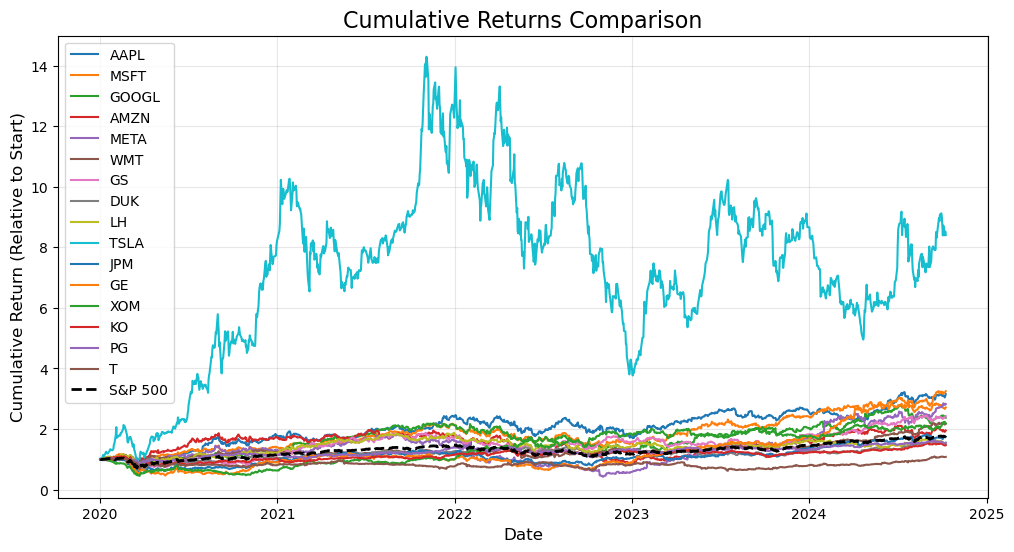

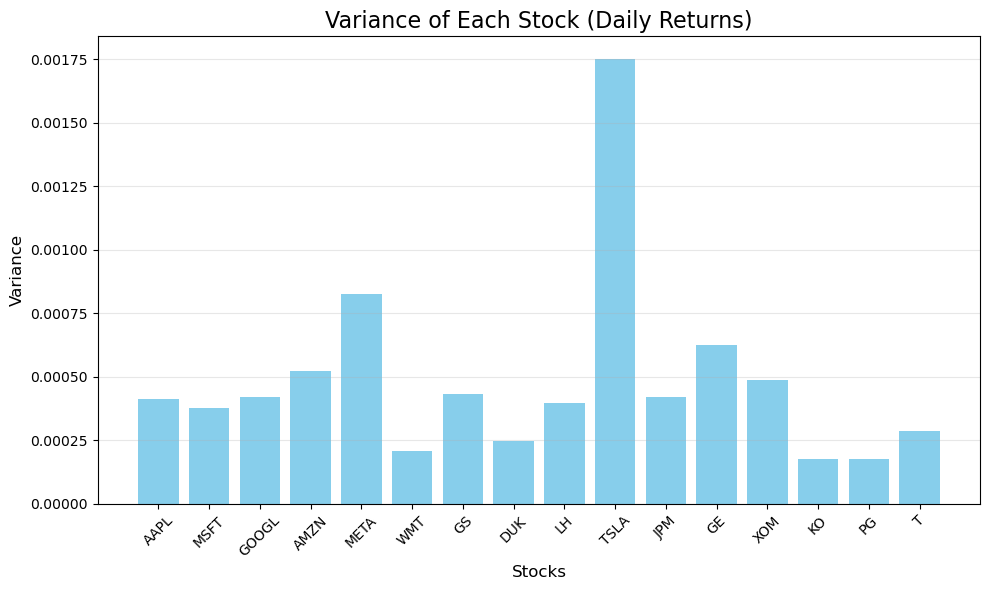

In [33]:
def plot_cumulative_returns(stock_close, index_close, symbols):
    """
    Plots the cumulative returns of each stock vs. the index,
    starting at 1.0 on the first available date.
    """
    data = stock_close.join(index_close, how="inner")  
    cum_returns = data.div(data.iloc[0])  # price / first_price

    plt.figure(figsize=(12, 6))
    for sym in symbols:
        if sym in cum_returns.columns:
            plt.plot(cum_returns[sym], label=sym)
    # Index is now a column named "S&P 500"
    if index_close.name in cum_returns.columns:
        plt.plot(cum_returns[index_close.name], 
                 label=index_close.name, linestyle="--", 
                 linewidth=2, color="black")

    plt.title("Cumulative Returns Comparison", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Cumulative Return (Relative to Start)", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_stock_variance(stock_close, symbols):
    """
    Plots the variance (based on daily returns) for each stock.
    """
    daily_returns = stock_close.pct_change().dropna()
    variances = daily_returns.var().reindex(symbols)

    plt.figure(figsize=(10, 6))
    plt.bar(variances.index, variances.values, color="skyblue")
    plt.title("Variance of Each Stock (Daily Returns)", fontsize=16)
    plt.xlabel("Stocks", fontsize=12)
    plt.ylabel("Variance", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# ------------- GENERATE THE PLOTS --------------------------------
plot_cumulative_returns(stock_close_prices, index_close_prices, symbols)
plot_stock_variance(stock_close_prices, symbols)


## Model and solution

In [34]:
# --- Step 2: Define Model Parameters ---
N = len(symbols)  # Number of stocks
T = len(stock_returns)  # Number of time periods

# Transaction cost coefficients (example values, adjust as needed)
transaction_costs = np.random.uniform(0.01, 0.05, N) 

# Constraints
budget = 1.0  # Total investment budget (100%)
w_max = 0.2  # Max allocation per stock

# Previous portfolio weights (starting at 0 for every stock)
w_prev = np.zeros(N)



Now, we define the objetcive function:
$$
\text{Minimize: } \mathcal{L}(w) = \sum_{t=1}^T \left( R_t^{\text{portfolio}} - R_t^{\text{index}} \right)^2 + \lambda \cdot \sum_{i=1}^N c_i \sqrt{|w_i - w_i^{\text{prev}}|}
$$

In [35]:
# --- Step 3: Define Objective Function ---
def objective(weights):
    # We convert to numpy arrays
    portfolio_arr = stock_returns.dot(weights).reindex(index_returns.index).to_numpy()
    index_arr = index_returns.to_numpy()
    
    # We compute tracking error as a scalar
    tracking_error = ((portfolio_arr - index_arr)**2).sum()

    # We compute transaction costs as a scalar
    trans_cost = (transaction_costs * np.sqrt(np.abs(weights - w_prev))).sum()

    # We convert to Python float
    return float(tracking_error + trans_cost)



Linear constraints:

In [36]:

# --- Step 4: Define Constraints ---
# Budget Constraint: Ensures the total portfolio allocation sums to 100%
def budget_constraint(weights):
    return budget - np.sum(weights)

# Non-Negativity: Prevents short selling
def non_negativity_constraint(weights):
    return weights  # Ensures all weights >= 0

constraints = [
    {'type': 'eq', 'fun': budget_constraint},
    {'type': 'ineq', 'fun': non_negativity_constraint},
]

# Bounds for each weight (0 <= w_i <= w_max)
bounds = [(0, w_max) for _ in range(N)]


Non-linear constraints:

In [37]:
# --- Step 4.1_ Non-linear Constraints---
# Portfolio variance should not exceed a risk threshold
risk_threshold = 0.03  # Threshold for variance 

# risk (variance) constraint: Controls the portfolio's variance, ensuring it doesn’t exceed a defined threshold.
def risk_constraint(weights):
    portfolio_variance = np.dot(weights.T, np.dot(stock_returns.cov().to_numpy(), weights))
    return risk_threshold - portfolio_variance  # Ensure variance <= threshold

constraints.append({'type': 'ineq', 'fun': risk_constraint})

# Diversification Constraint: Enforces minimum diversification using Shannon entropy.
entropy_threshold = 1.0  # Minimum entropy threshold (adjust as needed)

def diversification_constraint(weights):
    # We avoid log(0) by replacing 0 weights with a small positive value
    epsilon = 1e-6
    normalized_weights = np.clip(weights, epsilon, None)
    entropy = -np.sum(normalized_weights * np.log(normalized_weights))
    return entropy - entropy_threshold  # Ensure entropy >= threshold

constraints.append({'type': 'ineq', 'fun': diversification_constraint})


Solution:

In [38]:
# --- Step 5: Solution of the Optimization Problem ---
# we assume initial equal allocation
w0 = np.array([budget / N] * N)

result = minimize(
    fun=objective,
    x0=w0,
    bounds=bounds,
    constraints=constraints,
    method='SLSQP' 
)

# --- Step 6: Display Results ---
if result.success:
    optimal_weights = result.x
    print("Optimal Weights:", optimal_weights)
    print("Tracking Error + Transaction Cost:", result.fun)
else:
    print("Optimization failed:", result.message)

Optimal Weights: [1.70757459e-01 1.38126314e-08 4.21317778e-02 1.04122133e-01
 1.47086569e-01 0.00000000e+00 1.74353194e-08 1.99999991e-01
 1.87422633e-08 0.00000000e+00 1.91747608e-01 1.75837207e-10
 1.84231443e-08 1.63444942e-08 1.12236904e-01 3.19174878e-02]
Tracking Error + Transaction Cost: 0.07223244969558787


Visualization of the results

In [39]:
# --- Step 7: Visualization of the results ---
if result.success:
    # Create a DataFrame for the optimal weights
    results_df = pd.DataFrame({
        "Stock": symbols,
        "Optimal Weight": optimal_weights
    })
    results_df["Optimal Weight"] = results_df["Optimal Weight"].round(4)  # Round weights for better readability

    # Add total transaction costs and tracking error
    total_transaction_cost = (transaction_costs * np.sqrt(np.abs(optimal_weights - w_prev))).sum()
    tracking_error = ((stock_returns.dot(optimal_weights).reindex(index_returns.index).to_numpy() - index_returns.to_numpy())**2).sum()

    print("\n--- Optimization Results ---")
    print(results_df)

    # Print other relevant metrics
    print(f"\nTracking Error: {tracking_error:.4f}")
    print(f"Total Transaction Cost: {total_transaction_cost:.4f}")
    print(f"Objective Value (Tracking Error + Transaction Cost): {result.fun:.4f}")
else:
    print("Optimization failed:", result.message)



--- Optimization Results ---
    Stock  Optimal Weight
0    AAPL          0.1708
1    MSFT          0.0000
2   GOOGL          0.0421
3    AMZN          0.1041
4    META          0.1471
5     WMT          0.0000
6      GS          0.0000
7     DUK          0.2000
8      LH          0.0000
9    TSLA          0.0000
10    JPM          0.1917
11     GE          0.0000
12    XOM          0.0000
13     KO          0.0000
14     PG          0.1122
15      T          0.0319

Tracking Error: 0.0238
Total Transaction Cost: 0.0484
Objective Value (Tracking Error + Transaction Cost): 0.0722


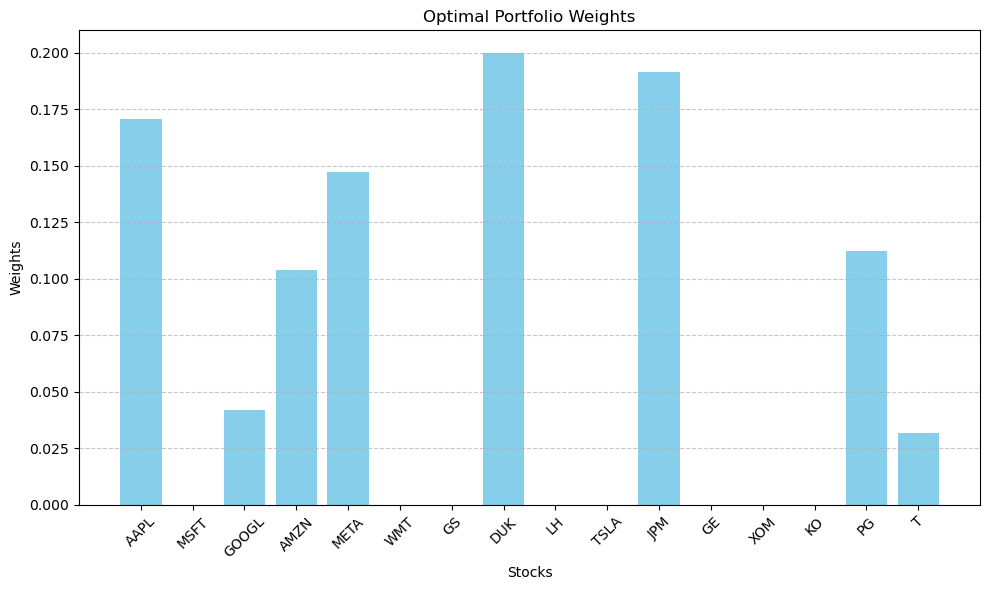

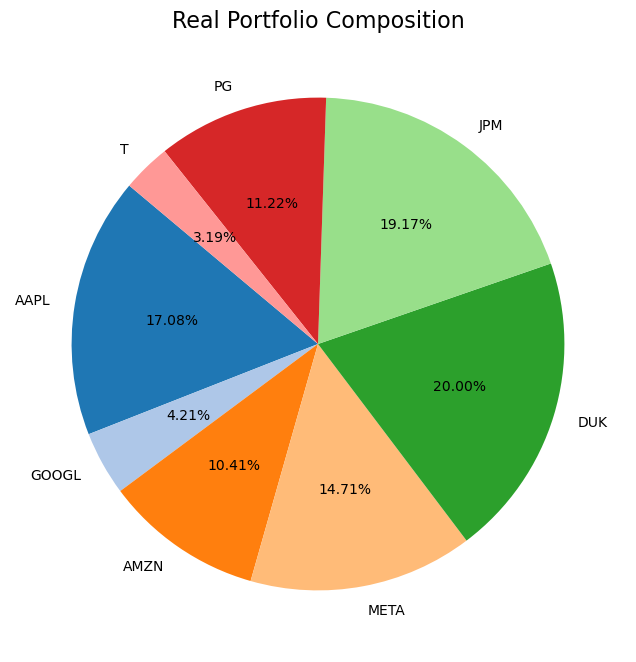

In [40]:
# Plot the optimal weights (Bar Chart)
plt.figure(figsize=(10, 6))
plt.bar(results_df["Stock"], results_df["Optimal Weight"], color="skyblue")
plt.title("Optimal Portfolio Weights")
plt.xlabel("Stocks")
plt.ylabel("Weights")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Modified Function to Plot Portfolio Composition (Pie Chart)
def plot_real_portfolio_composition(symbols, optimal_weights):
    # Filter stocks with non-zero weights
    non_zero_indices = optimal_weights > 0.01 # for clarity, we remove those stocks with no weight
    filtered_symbols = [symbols[i] for i in range(len(symbols)) if non_zero_indices[i]]
    filtered_weights = optimal_weights[non_zero_indices]

    # Plot pie chart with filtered data
    plt.figure(figsize=(8, 8))
    plt.pie(
        filtered_weights,
        labels=filtered_symbols,
        autopct=lambda p: f'{p:.2f}%',  # Format percentages to two decimal places
        startangle=140,
        colors=plt.cm.tab20.colors[:len(filtered_symbols)]
    )
    plt.title("Real Portfolio Composition", fontsize=16)
    plt.show()

# Check if optimization succeeded and plot the real portfolio composition
if result.success:
    plot_real_portfolio_composition(symbols, optimal_weights)
else:
    print("Optimization failed, no portfolio composition to display.")


### **Interpretation of Results**

The portfolio's allocation provides insightful information about the role each stock plays in replicating the performance of the S&P 500 index while adhering to the imposed constraints and balancing tracking error with transaction costs.

#### **Key Contributors**
- Stocks like **DUK** and **JPM** dominate the portfolio, each with weights close to the maximum allowable limit of 20%. This suggests that these stocks closely align with the overall performance and risk characteristics of the index. Their strong weights indicate their high relevance in replicating the index’s movements.
- **AAPL** also carries a significant weight of 17.08%, highlighting its importance in the portfolio as a major contributor to tracking the index.

#### **Supporting Stocks**
- Stocks such as **META** (14.71%) and **AMZN** (10.41%) play essential roles in enhancing the portfolio's ability to mimic the index. These allocations demonstrate a balance between selecting influential technology companies and maintaining diversification.
- **PG** (11.22%) provides exposure to the consumer goods sector, ensuring the portfolio captures some defensive characteristics of the index.

#### **Smaller Contributions**
- Stocks like **GOOGL** (4.21%) and **T** (3.19%) hold smaller weights in the portfolio. While their influence on the portfolio’s overall performance is limited, they contribute to diversification, reducing sector or stock-specific risks.

#### **Interpretation of Dominance**
The weights reflect the optimization’s strategy to focus on a few high-impact stocks (e.g., DUK, JPM) while supplementing the portfolio with smaller contributions from other sectors and industries. The dominance of DUK and JPM suggests that these stocks exhibit characteristics highly correlated with the index and are cost-efficient in terms of transaction costs for tracking performance.

---

### **Broader Implications**
- **Sector Representation**: The portfolio balances exposure across various sectors, with a notable focus on technology (AAPL, META, AMZN), finance (JPM), utilities (DUK), and consumer goods (PG). This sectoral balance enhances the portfolio's ability to replicate the broad market performance of the S&P 500.
- **Diversification**: While the portfolio is concentrated in a few key stocks, smaller weights for T and GOOGL ensure that it meets the diversification constraint, avoiding over-concentration in a handful of stocks.
- **Constraints and Realism**: The portfolio adheres to constraints like maximum weight per stock and transaction costs, reflecting practical limitations that align with real-world portfolio management.
